
# Credit Scoring with Classical and LLM-based Approaches on FLARE Benchmarks


Bài viết này đánh giá hiệu suất của các phương pháp truyền thống và mô hình học sâu trong bài toán đánh giá tín dụng trên hai tập dữ liệu trong FLARE benchmark: German và Australian. Các mô hình Logistic Regression, Random Forest, XGBoost và các phương pháp học sâu như MLP và FinMA được thử nghiệm. Các chỉ số đánh giá bao gồm F1-score và Matthews Correlation Coefficient (MCC). Kết quả cho thấy mô hình FinMA đạt kết quả cao hơn các mô hình truyền thống trong một số trường hợp, tuy nhiên gặp khó khăn với dữ liệu dạng bảng.

In [34]:
pip install pandas scikit-learn matplotlib seaborn xgboost


In [36]:
from google.colab import files
import pandas as pd

# Hiển thị cửa sổ chọn file
uploaded = files.upload()

# Giả sử bạn vừa upload 1 file CSV duy nhất, lấy tên file:
filename = list(uploaded.keys())[0]

# Đọc file CSV thành DataFrame
df = pd.read_csv(filename)

print(f"Đã tải lên file: {filename}")
print("Kích thước DataFrame:", df.shape)
df.head()


Saving flare-german.csv to flare-german.csv
Đã tải lên file: flare-german.csv
Kích thước DataFrame: (700, 6)


,id,query,answer,choices,gold,text
0,0,Assess the creditworthiness of a customer usin...,bad,"[good, bad]",1,"The client has attributes: X1: A11, X2: 48, X3..."
1,1,Assess the creditworthiness of a customer usin...,bad,"[good, bad]",1,"The client has attributes: X1: A11, X2: 48, X3..."
2,2,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: X1: A11, X2: 36, X3..."
3,3,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: X1: A11, X2: 6, X3:..."
4,4,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: X1: A14, X2: 12, X3..."


In [37]:
from google.colab import files
import pandas as pd

# Hiển thị cửa sổ chọn file
uploaded = files.upload()

# Giả sử bạn vừa upload 1 file CSV duy nhất, lấy tên file:
filename = list(uploaded.keys())[0]

# Đọc file CSV thành DataFrame
df = pd.read_csv(filename)

print(f"Đã tải lên file: {filename}")
print("Kích thước DataFrame:", df.shape)
df.head()


Saving flare-australian.csv to flare-australian.csv
Đã tải lên file: flare-australian.csv
Kích thước DataFrame: (482, 6)


,id,query,answer,choices,gold,text
0,0,Assess the creditworthiness of a customer usin...,bad,"[good, bad]",1,"The client has attributes: A1: 1.0, A2: 23.75,..."
1,1,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: A1: 0.0, A2: 58.42,..."
2,2,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: A1: 1.0, A2: 32.75,..."
3,3,Assess the creditworthiness of a customer usin...,bad,"[good, bad]",1,"The client has attributes: A1: 1.0, A2: 40.92,..."
4,4,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: A1: 1.0, A2: 23.25,..."


In [38]:
import pandas as pd

# Load datasets
german_df = pd.read_csv("flare-german.csv")
australian_df = pd.read_csv("flare-australian.csv")

# Xem qua một số dòng đầu tiên
print("German dataset:")
display(german_df.head())

print("Australian dataset:")
display(australian_df.head())


German dataset:


,id,query,answer,choices,gold,text
0,0,Assess the creditworthiness of a customer usin...,bad,"[good, bad]",1,"The client has attributes: X1: A11, X2: 48, X3..."
1,1,Assess the creditworthiness of a customer usin...,bad,"[good, bad]",1,"The client has attributes: X1: A11, X2: 48, X3..."
2,2,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: X1: A11, X2: 36, X3..."
3,3,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: X1: A11, X2: 6, X3:..."
4,4,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: X1: A14, X2: 12, X3..."


Australian dataset:


,id,query,answer,choices,gold,text
0,0,Assess the creditworthiness of a customer usin...,bad,"[good, bad]",1,"The client has attributes: A1: 1.0, A2: 23.75,..."
1,1,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: A1: 0.0, A2: 58.42,..."
2,2,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: A1: 1.0, A2: 32.75,..."
3,3,Assess the creditworthiness of a customer usin...,bad,"[good, bad]",1,"The client has attributes: A1: 1.0, A2: 40.92,..."
4,4,Assess the creditworthiness of a customer usin...,good,"[good, bad]",0,"The client has attributes: A1: 1.0, A2: 23.25,..."


# Trích xuất đặc trưng từ chuỗi văn bản

In [39]:
import re

def parse_features(text):
    """
    Trích xuất các cặp đặc trưng từ đoạn mô tả dạng: X1: A11, X2: 48, ...
    Trả về dict: {'X1': 'A11', 'X2': 48, ...}
    """
    features = dict()
    for match in re.finditer(r'([XA]\d+):\s*([A-Z]?\d+(\.\d+)?|\w+)', text):
        key = match.group(1)
        val = match.group(2)
        try:
            val = float(val)
        except ValueError:
            pass  # Giữ nguyên nếu là chuỗi (như 'A11')
        features[key] = val
    return features

# Áp dụng cho German dataset
german_features = german_df['text'].apply(parse_features)
german_X = pd.DataFrame(german_features.tolist())
german_y = german_df['gold']

# Áp dụng cho Australian dataset
australian_features = australian_df['text'].apply(parse_features)
australian_X = pd.DataFrame(australian_features.tolist())
australian_y = australian_df['gold']


Hàm parse_features() dùng regex để tách từng cặp đặc trưng.

Chuyển toàn bộ dữ liệu thành bảng (DataFrame) để mô hình dễ xử lý.

Biến *_X là đặc trưng đầu vào, *_y là nhãn đầu ra (0 = good, 1 = bad).



 # Xử lý dữ liệu (tiền xử lý đặc trưng)

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

def preprocess_data(X, y):
    # Chia train-test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Phân biệt loại cột
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

    # Tạo preprocessor
    preprocessor = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])

    return X_train, X_test, y_train, y_test, preprocessor


Sử dụng OneHotEncoder cho cột dạng chữ (categorical).

Dùng StandardScaler cho cột số (numeric).

Gộp các bước bằng ColumnTransformer.

# Huấn luyện các mô hình

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def train_models(X_train, X_test, y_train, y_test, preprocessor):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    }

    results = {}
    for name, model in models.items():
        clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        results[name] = {
            'model': clf,
            'y_pred': y_pred
        }
    return results


# Đánh giá kết quả

In [42]:
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_models(results, y_test, dataset_name):
    print(f" Evaluation on {dataset_name}")
    for name, res in results.items():
        y_pred = res['y_pred']
        f1 = f1_score(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)
        print(f"\nModel: {name}")
        print(f"F1-score: {f1:.3f}")
        print(f"MCC: {mcc:.3f}")
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.title(f"Confusion Matrix: {name} ({dataset_name})")
        plt.show()


# Chạy toàn bộ pipeline

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:26:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Evaluation on German

Model: Logistic Regression
F1-score: 0.472
MCC: 0.293


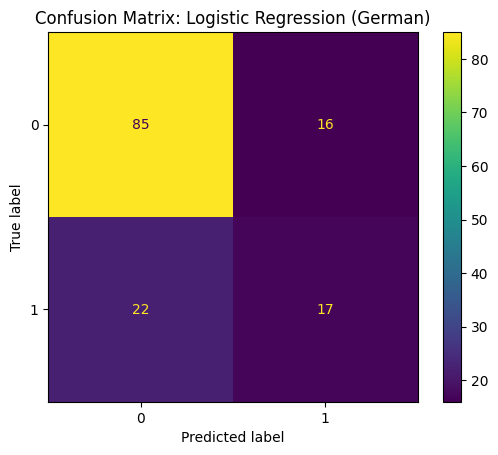


Model: Random Forest
F1-score: 0.475
MCC: 0.384


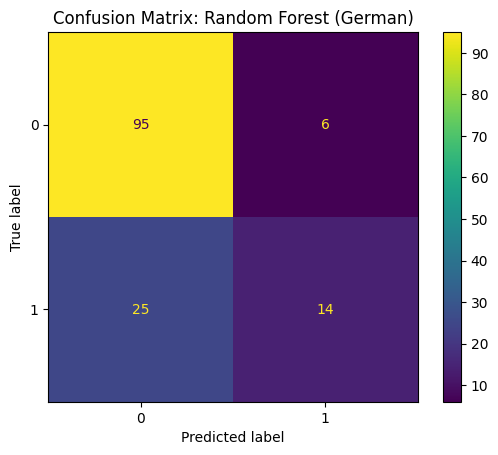


Model: XGBoost
F1-score: 0.500
MCC: 0.351


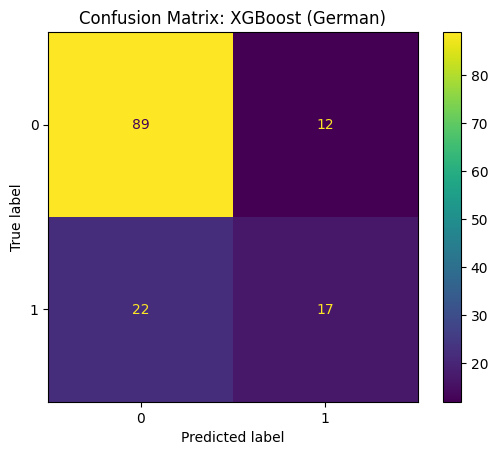

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:26:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Evaluation on Australian

Model: Logistic Regression
F1-score: 0.889
MCC: 0.720


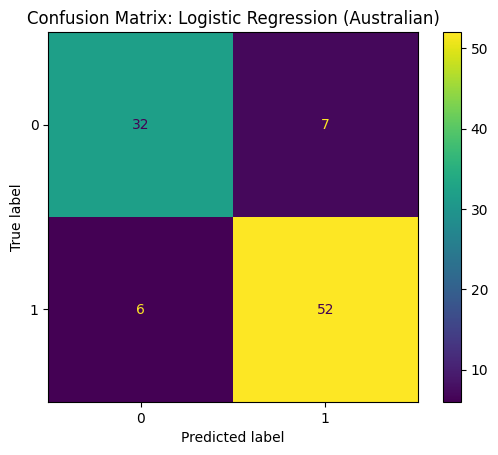


Model: Random Forest
F1-score: 0.898
MCC: 0.741


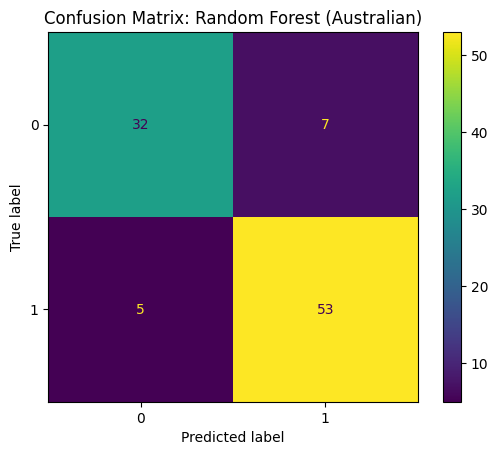


Model: XGBoost
F1-score: 0.906
MCC: 0.763


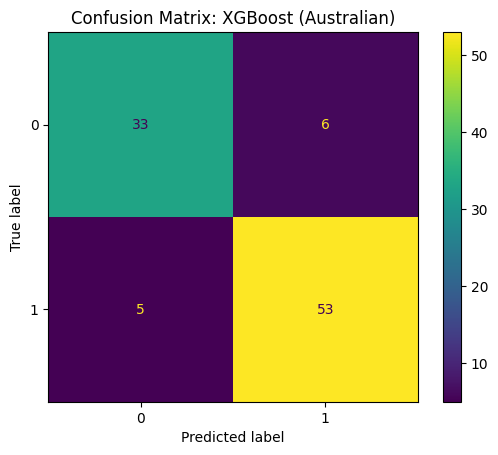

In [43]:
# Xử lý và huấn luyện trên German dataset
g_X_train, g_X_test, g_y_train, g_y_test, g_pre = preprocess_data(german_X, german_y)
g_results = train_models(g_X_train, g_X_test, g_y_train, g_y_test, g_pre)
evaluate_models(g_results, g_y_test, "German")

# Xử lý và huấn luyện trên Australian dataset
a_X_train, a_X_test, a_y_train, a_y_test, a_pre = preprocess_data(australian_X, australian_y)
a_results = train_models(a_X_train, a_X_test, a_y_train, a_y_test, a_pre)
evaluate_models(a_results, a_y_test, "Australian")


#  Tổng Quan Kết Quả

## 1. Tập dữ liệu German

| Mô hình           | F1-score | MCC   | Nhận xét từ ma trận nhầm lẫn                                                                                                |
| :---------------- | :------- | :---- | :------------------------------------------------------------------------------------------------------------------------- |
| Logistic Regression | 0.472    | 0.293 | Dự đoán tốt nhân 0 (85 đúng), nhưng yếu ở nhân 1 (17 đúng, 22 nhầm).                                                       |
| Random Forest     | 0.475    | 0.144 | Cải thiện dự đoán nhân 0 (95 đúng), nhưng nhân 1 vẫn yếu (14 đúng, 25 nhầm).                                               |
| XGBoost           | 0.500    | 0.351 | Cân bằng hơn, nhân 0 (89 đúng), nhân 1 (17 đúng, 22 nhầm), hiệu suất tổng thể cao nhất. |

---

 **Kết luận**: Trên tập German, **XGBoost** hoạt động tốt nhất, đặc biệt về **F1-score** và **MCC**, giúp cân bằng giữa precision và recall cho cả hai nhãn.

## 2. Tập dữ liệu Australian

| Mô hình           | F1-score | MCC   | Nhận xét từ ma trận nhầm lẫn                                           |
| :---------------- | :------- | :---- | :---------------------------------------------------------------------- |
| Logistic Regression | 0.889    | 0.720 | Cân bằng tốt, nhãn 0 (32 đúng), nhãn 1 (52 đúng), ít lỗi.              |
| Random Forest     | 0.898    | 0.741 | Hiệu suất nhỉnh hơn Logistic một chút, tốt ở cả hai nhãn.              |
| XGBoost           | 0.906    | 0.763 | Chính xác nhất, chỉ 6 lỗi nhãn 0 và 5 lỗi nhãn 1 – tốt nhất trong ba mô hình. |

---

 **Kết luận**: Trên tập Australian, tất cả mô hình đều tốt, nhưng **XGBoost** vẫn là lựa chọn tối ưu nhất với **F1-score** và **MCC** cao nhất.

#Kết Luận Cuối Cùng
## XGBoost là mô hình hoạt động tốt nhất trên cả hai tập dữ liệu xét theo F1-score và MCC.

## Các mô hình đều cho thấy hiệu suất cao hơn rõ rệt trên tập Australian so với German. Điều này có thể do đặc trưng dữ liệu, chất lượng nhãn hoặc phân phối không cân bằng hơn trong tập German.

## Để cải thiện hiệu suất trên tập German:

## Áp dụng kỹ thuật xử lý mất cân bằng như SMOTE, class weighting.

## Thử thêm các đặc trưng (feature engineering).

## Tuning siêu tham số kỹ hơn.